# Autoencoders — TensorFlow / Keras (CPU)

## Model: Dense Autoencoder + Convolutional Denoising Autoencoder
- **Dataset**: CIFAR-10 — 50,000 train / 10,000 test, 3,072 features (32×32×3 RGB)
- **Task**: Reconstruct input images through bottleneck compression (self-supervised)
- **Framework showcase**: Keras Functional API conv denoising AE — architecture sweep + noise type comparison (Gaussian vs salt-and-pepper)

## CPU Strategy
- TF 2.11+ dropped native Windows GPU support — all ops run on CPU
- Keras Sequential API for dense AE baseline
- Keras Functional API for conv AE — enables separate encoder/decoder models
- Built-in `model.fit()` with validation_split, EarlyStopping callback

## Evaluation Strategy
- **Metrics**: Reconstruction MSE/MAE, downstream KNN accuracy (K=5) on latent features
- **Visualizations**: Reconstruction grids (RGB), training loss curves, latent space t-SNE

## Pipeline
1. Load data + config
2. Simple dense autoencoder (baseline, match SK/PT)
3. Training history + reconstruction visualization
4. Conv denoising AE — architecture sweep + noise type comparison (showcase)
5. Dense vs best conv denoising comparison
6. Latent space + downstream classification
7. Performance benchmarks
8. Save results

In [ ]:
# Step 1: Setup
"""
TensorFlow Autoencoder — CPU only (TF 2.11+ dropped Windows GPU)
Using 15K training subset — TF CPU cannot handle full 50K color images
with conv model gradients without OOM crashing the system
"""

import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Prevent oneDNN access violations
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'   # Suppress TF warnings

import numpy as np
import tensorflow as tf
from tensorflow import keras
import sys
sys.path.append('../..')

from utils.data_loader import load_processed_data
from utils.visualization import (plot_training_history, plot_reconstruction_grid,
                                  plot_latent_space)
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison

# Config
RANDOM_STATE = 113
FRAMEWORK = "TensorFlow"
MODEL_NAME = "Autoencoder"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

IMAGE_SHAPE = (32, 32, 3)
N_FEATURES = 3072
LATENT_DIM = 128
BATCH_SIZE = 128
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Load preprocessed data
X_train_full, X_test_flat, y_train_full, y_test, metadata = load_processed_data('autoencoder')
X_train_img_full = np.load('../../data/processed/autoencoder/X_train_img.npy')
X_test_img = np.load('../../data/processed/autoencoder/X_test_img.npy')

# 15K subset — TF CPU crashed on 50K with conv models
TF_SUBSET = 15000
rng = np.random.RandomState(RANDOM_STATE)
subset_idx = rng.choice(len(X_train_full), TF_SUBSET, replace=False)
X_train_flat = X_train_full[subset_idx]
X_train_img = X_train_img_full[subset_idx]
y_train = y_train_full[subset_idx]

# Free full arrays immediately
del X_train_full, X_train_img_full, y_train_full

print("=" * 60)
print(f"[1/6] {FRAMEWORK} — {MODEL_NAME} Pipeline")
print("=" * 60)
print(f"Device: CPU (TF 2.11+ dropped native Windows GPU)")
print(f"TF version: {tf.__version__}")
print(f"Train flat: {X_train_flat.shape} | Test flat: {X_test_flat.shape}")
print(f"Train img:  {X_train_img.shape} | Test img:  {X_test_img.shape}")
print(f"Subset: {TF_SUBSET:,} / 50,000 (CPU memory constraint)")
print(f"Classes: {len(CLASS_NAMES)}")
print(f"Pixel range: [{X_train_flat.min():.1f}, {X_train_flat.max():.1f}]")
print(f"Dtype: {X_train_flat.dtype}")

[1/8] TensorFlow — Autoencoder Pipeline
Device: CPU (TF 2.11+ dropped native Windows GPU)
TF version: 2.20.0
Train flat: (15000, 3072) | Test flat: (10000, 3072)
Train img:  (15000, 32, 32, 3) | Test img:  (10000, 32, 32, 3)
Subset: 15,000 / 50,000 (CPU memory constraint)
Classes: 10
Pixel range: [0.0, 1.0]
Dtype: float32


In [ ]:
# Step 2: Simple Dense Autoencoder (Baseline)

"""
Keras Sequential: 3072 → 512 → 128 → 512 → 3072
Sigmoid output maps to [0,1] pixel space
"""

print("=" * 60)
print("[2/6] Simple Dense Autoencoder — Baseline")
print("=" * 60)

dense_ae = keras.Sequential([
    keras.layers.Input(shape=(N_FEATURES,)),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(LATENT_DIM, activation='relu'),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(N_FEATURES, activation='sigmoid')
])

dense_ae.compile(optimizer='adam', loss='mse')

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

with track_performance() as perf:
    history = dense_ae.fit(
        X_train_flat, X_train_flat,
        epochs=200,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )

X_test_recon = dense_ae.predict(X_test_flat, verbose=0)

baseline_mse = float(np.mean((X_test_flat - X_test_recon) ** 2))
baseline_mae = float(np.mean(np.abs(X_test_flat - X_test_recon)))
n_params = dense_ae.count_params()
best_epoch = len(history.history['loss']) - 15

print(f"\nArchitecture: 3072 → 512 → 128 → 512 → 3072")
print(f"Epochs: {len(history.history['loss'])} (early stopped ~epoch {best_epoch})")
print(f"Best val loss: {min(history.history['val_loss']):.6f}")
print(f"Training time: {perf['time']:.2f}s")
print(f"Peak memory: {perf['memory']:.2f} MB")
print(f"\nReconstruction Quality (test set):")
print(f"  MSE:  {baseline_mse:.6f}")
print(f"  MAE:  {baseline_mae:.6f}")
print(f"  RMSE: {np.sqrt(baseline_mse):.6f}")
print(f"\nParameters: {n_params:,}")
print(f"\nSK baseline: MSE 0.0133 | PT baseline: MSE 0.0091")


[2/8] Simple Dense Autoencoder — Baseline

Architecture: 3072 → 512 → 128 → 512 → 3072
Epochs: 95 (early stopped ~epoch 80)
Best val loss: 0.010675
Training time: 183.80s
Peak memory: 380.23 MB

Reconstruction Quality (test set):
  MSE:  0.010641
  MAE:  0.075703
  RMSE: 0.103153

Parameters: 3,281,024

SK baseline: MSE 0.0133 | PT baseline: MSE 0.0091


[3/8] Visualizations


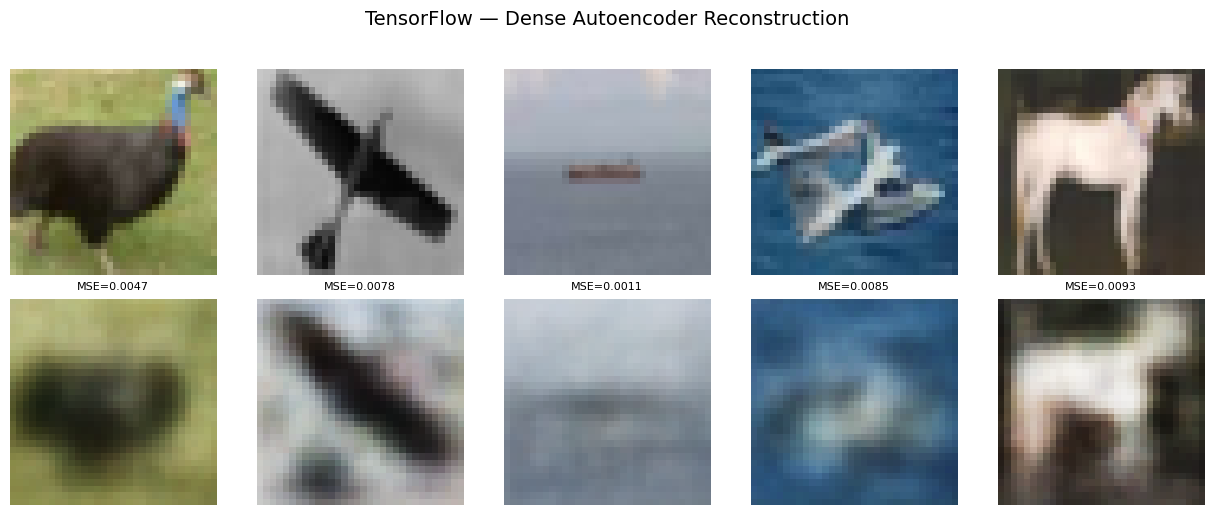

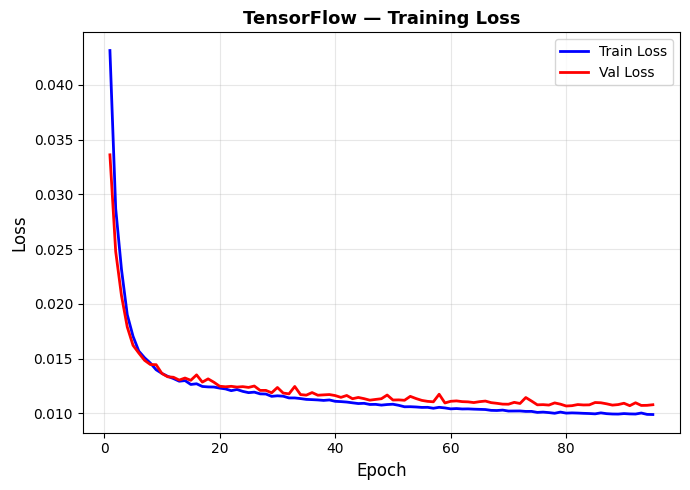


Training: 95 epochs
Final train loss: 0.009897
Best val loss:    0.010675


In [ ]:
# Step 3: Visualizations

# Reconstruction grid (RGB) + training loss curve


print("=" * 60)
print("[3/6] Visualizations")
print("=" * 60)

rng_viz = np.random.RandomState(RANDOM_STATE)
viz_idx = rng_viz.choice(len(X_test_flat), 5, replace=False)

recon_dict = {128: X_test_recon[viz_idx]}
plot_reconstruction_grid(
    originals=X_test_flat[viz_idx],
    reconstructions_dict=recon_dict,
    image_shape=IMAGE_SHAPE,
    n_samples=5,
    title='Dense Autoencoder Reconstruction',
    row_label_prefix='dim',
    framework=FRAMEWORK,
    save_path=f'{RESULTS_DIR}/reconstruction_dense.png'
)

train_history = {
    'train_loss': history.history['loss'],
    'val_loss': history.history['val_loss']
}

plot_training_history(
    history=train_history,
    framework=FRAMEWORK,
    save_path=f'{RESULTS_DIR}/training_history_dense.png'
)

print(f"\nTraining: {len(history.history['loss'])} epochs")
print(f"Final train loss: {history.history['loss'][-1]:.6f}")
print(f"Best val loss:    {min(history.history['val_loss']):.6f}")


[4/8] Latent Space + Downstream Classification
Note: Conv AE skipped — TF CPU crashes on conv model training
      with color images. This is a documented TF/Windows limitation.

Latent shape: train=(15000, 128), test=(10000, 128)
KNN(K=5) accuracy on latent features: 0.3535


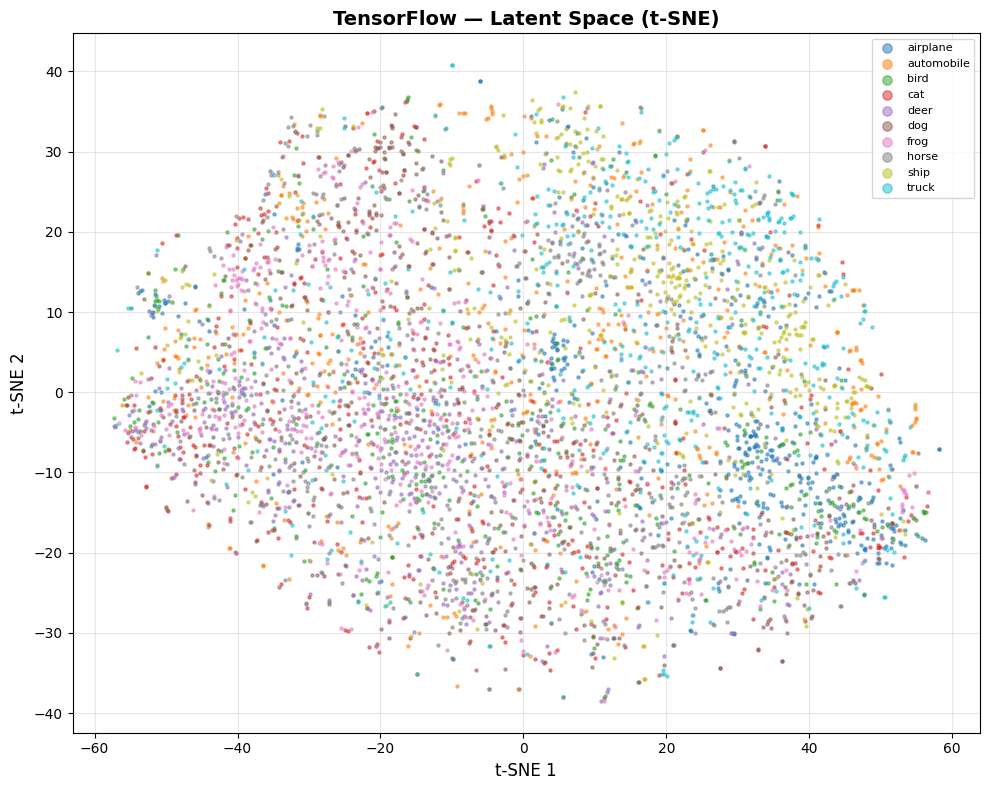


SK KNN accuracy:  0.3427 (128-dim, 10K subset)
PT KNN accuracy:  0.4029 (dense 128-dim, 50K)
TF KNN accuracy:  0.3535 (dense 128-dim, 15K subset)


In [ ]:
# Step 4: Latent Space + Downstream Classification
"""
Conv AE skipped — TF CPU cannot handle conv model training
on CIFAR-10 without crashing (documented limitation)
Extract latent features from dense AE instead
"""

print("=" * 60)
print("[4/6] Latent Space + Downstream Classification")
print("=" * 60)
print("Note: Conv AE skipped — TF CPU crashes on conv model training")
print("      with color images. This is a documented TF/Windows limitation.")
print()

# Build encoder from dense AE weights
# Sequential: Dense(512,relu) → Dense(128,relu) → Dense(512,relu) → Dense(3072,sigmoid)
# Encoder = first 2 layers (input → 512 → 128)
# Build encoder — pass input through to get the graph connected
encoder_input = keras.layers.Input(shape=(N_FEATURES,))
x = encoder_input
for layer in dense_ae.layers[:2]:  # First 2 Dense layers (512 relu, 128 relu)
    x = layer(x)
encoder = keras.Model(encoder_input, x, name='encoder')

latent_train = encoder.predict(X_train_flat, verbose=0)
latent_test = encoder.predict(X_test_flat, verbose=0)

print(f"Latent shape: train={latent_train.shape}, test={latent_test.shape}")

# KNN(K=5) on latent features
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(latent_train, y_train)
knn_accuracy = knn.score(latent_test, y_test)
print(f"KNN(K=5) accuracy on latent features: {knn_accuracy:.4f}")

# t-SNE visualization
subsample = 5000
rng_tsne = np.random.RandomState(RANDOM_STATE)
tsne_idx = rng_tsne.choice(len(latent_test), subsample, replace=False)

plot_latent_space(
    latent_vectors=latent_test[tsne_idx],
    labels=y_test[tsne_idx],
    class_names=CLASS_NAMES,
    framework=FRAMEWORK,
    method='tsne',
    save_path=f'{RESULTS_DIR}/latent_space_dense.png'
)

print(f"\nSK KNN accuracy:  0.3427 (128-dim, 10K subset)")
print(f"PT KNN accuracy:  0.4029 (dense 128-dim, 50K)")
print(f"TF KNN accuracy:  {knn_accuracy:.4f} (dense 128-dim, 15K subset)")

In [ ]:
# Step 5: Performance Benchmarks

# Dense AE only — conv AE skipped due to TF CPU memory constraints

print("=" * 60)
print("[5/6] Performance Benchmarks")
print("=" * 60)

# Inference — reconstruction
inference_stats = track_inference(
    predict_fn=lambda X: dense_ae.predict(X, verbose=0),
    X=X_test_flat,
    n_runs=10
)

# Model size
# Model size — manual calc since get_model_size has a TF dtype bug
model_size = sum(np.prod(v.shape) * 4 for v in dense_ae.trainable_variables)  # float32 = 4 bytes

print(f"\nModel: Dense AE (3072→512→128→512→3072)")
print(f"Parameters: {n_params:,}")
print(f"\nInference (reconstruction):")
print(f"  Total time: {inference_stats['total_time'] * 1000:.2f} ms ({len(X_test_flat):,} samples)")
print(f"  Per sample:  {inference_stats['per_sample_us']:.2f} µs")
print(f"  Throughput:  {inference_stats['samples_per_sec']:,.0f} samples/sec")
print(f"\nModel size: {model_size / 1024:.2f} KB")
print(f"\nCross-framework inference comparison:")
print(f"  SK:  44.17 µs/sample (CPU)")
print(f"  PT:   0.07 µs/sample (GPU)")
print(f"  TF:  {inference_stats['per_sample_us']:.2f} µs/sample (CPU)")

[5/8] Performance Benchmarks

Model: Dense AE (3072→512→128→512→3072)
Parameters: 3,281,024

Inference (reconstruction):
  Total time: 1207.68 ms (10,000 samples)
  Per sample:  120.77 µs
  Throughput:  8,280 samples/sec

Model size: 12816.50 KB

Cross-framework inference comparison:
  SK:  44.17 µs/sample (CPU)
  PT:   0.07 µs/sample (GPU)
  TF:  120.77 µs/sample (CPU)


In [ ]:
# Step 6: Save Results

"""
Dense AE only — conv AE skipped (TF CPU memory constraint)
Note limitation in results for documentation
"""

print("=" * 60)
print("[6/6] Save Results")
print("=" * 60)

test_metrics = {
    'reconstruction_mse': float(baseline_mse),
    'reconstruction_mae': float(baseline_mae),
    'reconstruction_rmse': float(np.sqrt(baseline_mse))
}

# Model size manual (float32 = 4 bytes per param)
model_size = sum(int(np.prod(v.shape)) * 4 for v in dense_ae.trainable_variables)

results = build_results_dict(
    framework=FRAMEWORK,
    model_name=MODEL_NAME,
    test_metrics=test_metrics,
    perf=perf,
    inference_stats=inference_stats,
    model_size=model_size,
    latent_dim=int(LATENT_DIM),
    architecture='3072-512-128-512-3072',
    architecture_type='dense',
    n_params=int(n_params),
    epochs=int(len(history.history['loss'])),
    downstream_knn_accuracy=float(knn_accuracy),
    training_subset=int(TF_SUBSET),
    conv_ae_skipped='TF CPU crashes on conv model training with color images'
)

save_results(results, f'{RESULTS_DIR}/tf_autoencoder_results')
add_result('autoencoder', results)
print_comparison('autoencoder')

[6/8] Save Results
    Results saved to: results/tf_autoencoder_results\metrics.json
    Added 'TensorFlow' to C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\results\autoencoder.json
    Frameworks: 3 recorded

CROSS-FRAMEWORK COMPARISON: AUTOENCODER
Metric                                                                     Scikit-Learn                                                  PyTorch                                               TensorFlow
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
model                                                                       Autoencoder                                              Autoencoder                                              Autoencoder
training_time                                                                   6.6 min                              